In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
df = pd.read_csv('data/insurance.csv')
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (1244, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1244 non-null   int64  
 1   sex       1244 non-null   str    
 2   bmi       1244 non-null   float64
 3   children  1244 non-null   int64  
 4   smoker    1244 non-null   str    
 5   region    1244 non-null   str    
 6   charges   1244 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 68.2 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1244.000000,1244.000000,1244.000000,1244.000000
mean,39.088424,30.582858,1.103698,13198.216342
std,14.055295,6.159513,1.215885,12001.805804
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.060000,0.000000,4733.635288
50%,39.000000,30.210000,1.000000,9382.033000
75%,51.000000,34.618750,2.000000,16579.959053
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

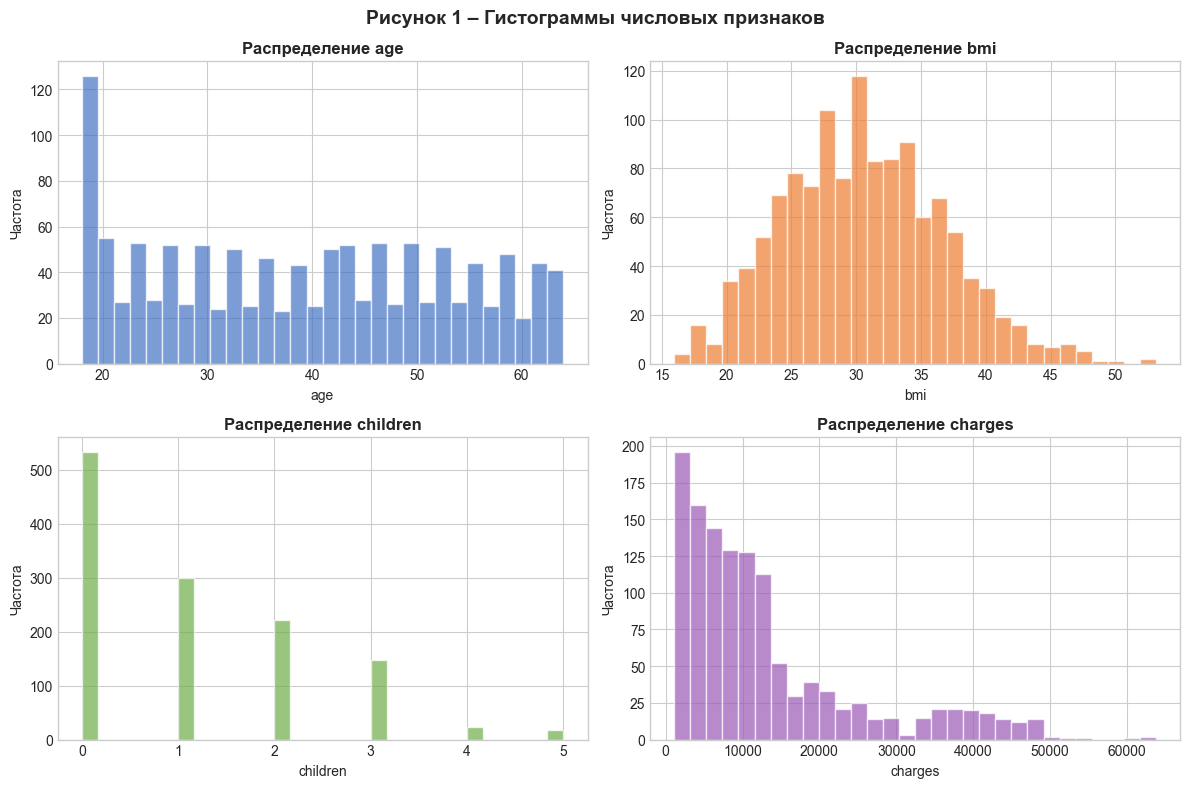

✅ Рисунок 1 сохранён


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
numeric_cols = ['age', 'bmi', 'children', 'charges']
colors = ['#4472C4', '#ED7D31', '#70AD47', '#9B59B6']

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.7)
    axes[i].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.suptitle('Рисунок 1 – Гистограммы числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Рисунок 1 сохранён")

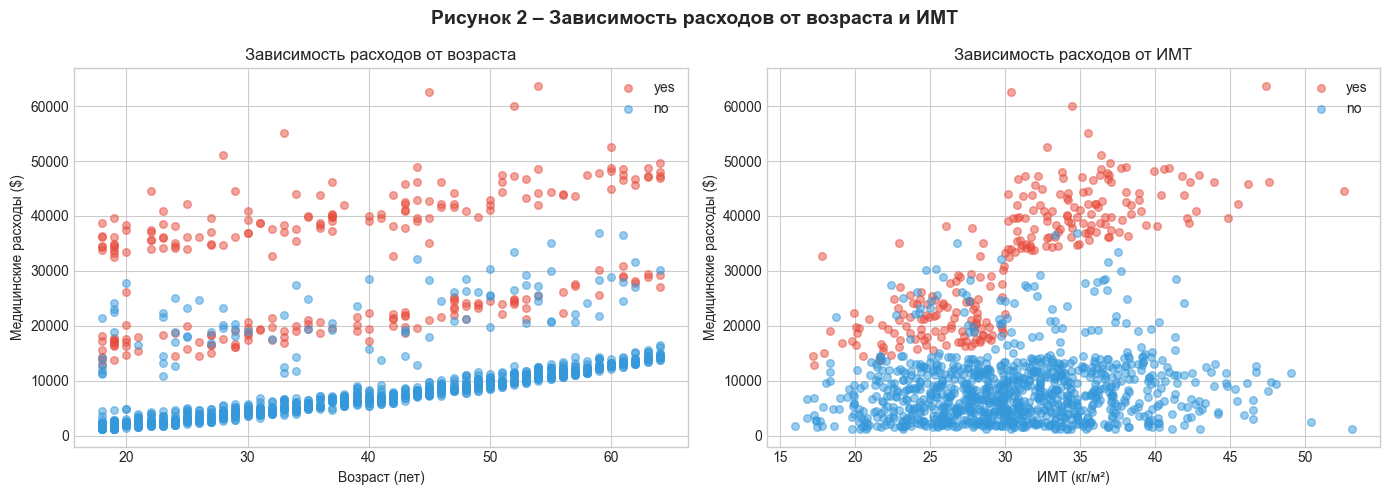

✅ Рисунок 2 сохранён


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_smoker = {'yes': '#E74C3C', 'no': '#3498DB'}

for status, color in colors_smoker.items():
    subset = df[df['smoker'] == status]
    axes[0].scatter(subset['age'], subset['charges'], c=color, alpha=0.5, label=status, s=30)
    axes[1].scatter(subset['bmi'], subset['charges'], c=color, alpha=0.5, label=status, s=30)

axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Медицинские расходы ($)')
axes[0].set_title('Зависимость расходов от возраста')
axes[0].legend()

axes[1].set_xlabel('ИМТ (кг/м²)')
axes[1].set_ylabel('Медицинские расходы ($)')
axes[1].set_title('Зависимость расходов от ИМТ')
axes[1].legend()

plt.suptitle('Рисунок 2 – Зависимость расходов от возраста и ИМТ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig2_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Рисунок 2 сохранён")

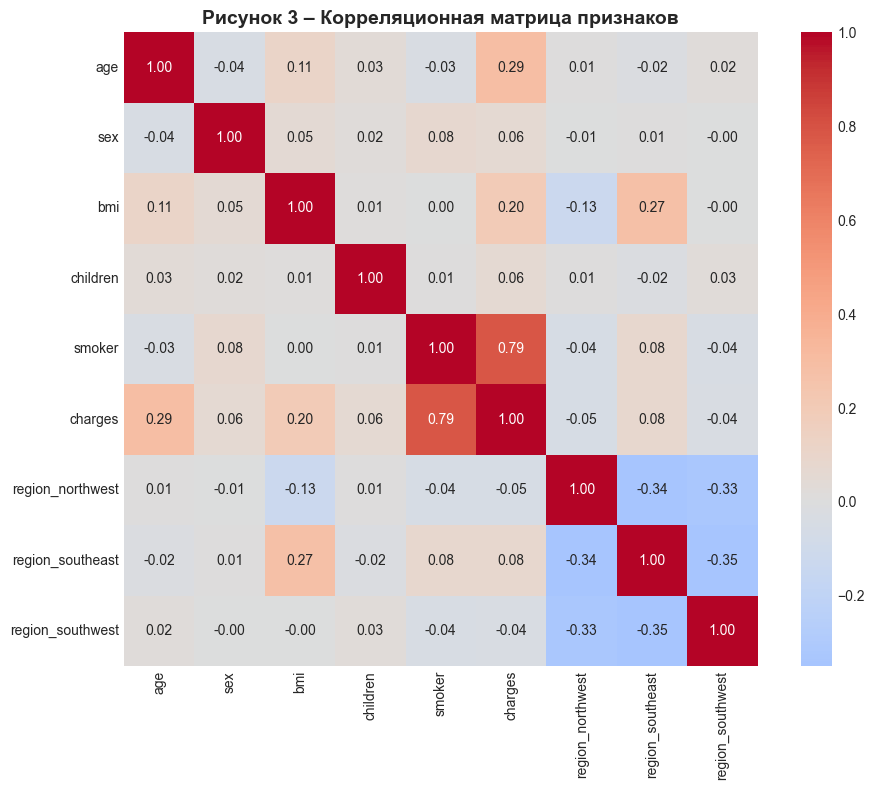

✅ Рисунок 3 сохранён


In [8]:
df_corr = df.copy()
df_corr['sex'] = (df_corr['sex'] == 'male').astype(int)
df_corr['smoker'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr = pd.get_dummies(df_corr, columns=['region'], drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Рисунок 3 – Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Рисунок 3 сохранён")

In [9]:
print("="*60)
print("ВЫВОДЫ ПО EDA")
print("="*60)
print("""
1. Ключевой предиктор — статус курения (smoker):
   - Корреляция с расходами: +0.79
   - Курильщики платят в 3-4 раза больше

2. Вторичные факторы:
   - age (корреляция +0.30)
   - bmi (корреляция +0.20)

3. Категориальные признаки преобразуются:
   - sex → 0/1
   - smoker → 0/1
   - region → one-hot encoding

4. Для линейной регрессии и нейронной сети требуется нормализация (StandardScaler)

5. Разбивка данных: 60% train / 20% val / 20% test
""")

ВЫВОДЫ ПО EDA

1. Ключевой предиктор — статус курения (smoker):
   - Корреляция с расходами: +0.79
   - Курильщики платят в 3-4 раза больше

2. Вторичные факторы:
   - age (корреляция +0.30)
   - bmi (корреляция +0.20)

3. Категориальные признаки преобразуются:
   - sex → 0/1
   - smoker → 0/1
   - region → one-hot encoding

4. Для линейной регрессии и нейронной сети требуется нормализация (StandardScaler)

5. Разбивка данных: 60% train / 20% val / 20% test

